In [2]:
import os
import getpass
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

In [3]:
!pip install -q kaggle
from kaggle.api.kaggle_api_extended import KaggleApi

username = input("Enter your Kaggle Username: ")
api_key = getpass.getpass("Enter your Kaggle API Key: ")

os.environ["KAGGLE_USERNAME"] = username
os.environ["KAGGLE_KEY"] = api_key

kaggle = KaggleApi()
kaggle.authenticate()

dataset = "blastchar/telco-customer-churn"

kaggle.dataset_download_files(
    dataset=dataset,
    path="./",
    unzip=True
)

print("Dataset download is successful.")

Enter your Kaggle Username: varun22
Enter your Kaggle API Key: ··········
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
Dataset download is successful.


In [8]:
#Task1
customer_data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("First Five Records")
customer_data.head()

First Five Records


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
#Task1
numerical_features = customer_data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = customer_data.select_dtypes(
    include=["object"]
).columns.tolist()
print("Numerical Features")
print(numerical_features)
print("\nCategorical Features")
print(categorical_features)
print("\nTarget Variable")
print("Churn")


Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Features
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Target Variable
Churn


In [11]:
#Task2
print("Missing Values in Each Column:")
print("\n")
print(customer_data.isnull().sum())

Missing Values in Each Column:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [12]:
#Task2
customer_data["TotalCharges"] = pd.to_numeric(
    customer_data["TotalCharges"],
    errors="coerce"
)
print("Missing values after conversion:")
print(customer_data.isnull().sum())
customer_data["TotalCharges"].fillna(
    customer_data["TotalCharges"].median(),
    inplace=True
)
print("\nMissing values after handling:")
print(customer_data.isnull().sum())

Missing values after conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0

In [16]:
#Task2
encoder = LabelEncoder()
for column in customer_data.columns:
    if customer_data[column].dtype == "object":
        customer_data[column] = encoder.fit_transform(
            customer_data[column]
        )
print("Categorical variables encoded successfully.")
customer_data.head()

Categorical variables encoded successfully.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [14]:
#Task2
X = customer_data.drop("Churn", axis=1)
y = customer_data["Churn"]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 20)
Target Shape: (7043,)


In [15]:
#Task2
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (5634, 20)
Testing Features : (1409, 20)
Training Labels : (5634,)
Testing Labels : (1409,)


In [17]:
#Task3
from sklearn.linear_model import LogisticRegression
churn_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)
churn_classifier.fit(X_train, y_train)
print("Logistic Regression model is trained successfully.")

Logistic Regression model is trained successfully.


In [18]:
#Task3
predicted_churn = churn_classifier.predict(X_test)
prediction_result = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Predicted Churn": predicted_churn
})
prediction_result.head(10)

,Actual Churn,Predicted Churn
0,0,0
1,0,1
2,0,0
3,0,0
4,0,0
5,0,1
6,0,0
7,0,0
8,0,0
9,1,0


Model Performance
-----------------------------------
Accuracy  : 0.7921
Precision : 0.6254
Recall    : 0.5401
F1-Score  : 0.5796


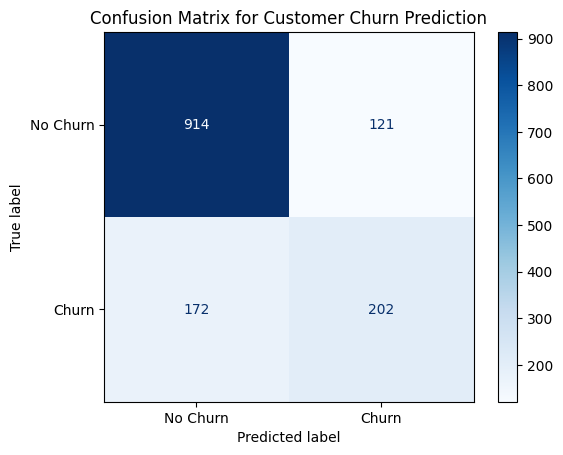

In [24]:
#Task4
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
model_accuracy = accuracy_score(y_test, predicted_churn)
model_precision = precision_score(y_test, predicted_churn)
model_recall = recall_score(y_test, predicted_churn)
model_f1 = f1_score(y_test, predicted_churn)
print("Model Performance")
print("-" * 35)
print(f"Accuracy  : {model_accuracy:.4f}")
print(f"Precision : {model_precision:.4f}")
print(f"Recall    : {model_recall:.4f}")
print(f"F1-Score  : {model_f1:.4f}")
conf_matrix = confusion_matrix(y_test, predicted_churn)
display = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=["No Churn", "Churn"]
)
display.plot(cmap="Blues")
plt.title("Confusion Matrix for Customer Churn Prediction")
plt.show()

Task 4
## Observations

1. The Logistic Regression model achieved an overall **accuracy of 79.21%**, indicating that it correctly classified the majority of customers as churn or non-churn.

2. The confusion matrix shows that **914 non-churn customers** and **202 churn customers** were classified correctly. However, the model incorrectly predicted **121 non-churn customers as churn** and failed to identify **172 customers who actually churned**, indicating that predicting churn remains more challenging.

3. The **Precision (62.54%)**, **Recall (54.01%)**, and **F1-score (57.96%)** suggest that the model performs reasonably well but misses a noticeable number of actual churn cases. This indicates that while the model is suitable as a baseline classifier, its performance could be improved using advanced classification algorithms or feature engineering.

Task 5
## Conclusion

In this assignment, a Logistic Regression model was developed to predict customer churn using the selected customer attributes. The model achieved an **accuracy of 79.21%**, demonstrating that it can correctly classify most customers into churn and non-churn categories. The obtained precision, recall, and F1-score indicate moderate performance, showing that the model is effective in identifying many churn cases but still misses some customers who actually leave the service. The confusion matrix further highlights that the model predicts non-churn customers more accurately than churn customers. Factors such as contract type, tenure, monthly charges, and payment method contribute significantly to customer churn prediction. A limitation of Logistic Regression is that it assumes a linear relationship between the input features and the log-odds of the target variable, which may not capture complex patterns in customer behavior. This makes it a good baseline model but not always the most accurate choice.